# 13 — Detecting Parasitic Single-Crystal Spots on a Multi-Panel Detector

**Time: ~20 minutes.** Builds on Notebooks 09 and 11.

## What you'll learn

Powder-diffraction experiments routinely pick up unwanted **parasitic
Bragg spots** from:

- A sample-environment window (Be, sapphire, diamond)
- Diamond-anvil cell gaskets
- Capillary walls (single-crystal sapphire or kapton with oriented domains)
- An occasional "rogue" large grain in a sample that's supposed to be powder

These spots are *localised in azimuth (η)* on a powder ring — the ring
itself is approximately η-uniform, but the parasitic crystal hits the
Bragg condition only over a few degrees of η, producing a bright spot
sitting on top of the ring.

The principled way to catch this is **azimuthal sigma-clipping on
I(R, η)**: for each radial bin, compute the median + MAD over η, flag
pixels exceeding `median + n_sigma · 1.4826 · MAD`. That's exactly
what `midas_integrate_v2.streaming.azimuthal_sigma_clip` does.

This notebook walks through the workflow on a **4-panel synthetic
detector** — the geometry pattern shared by:

- **Pilatus 2M / 6M** (8 tiles in a 4×2 or 5×2 grid)
- **Eiger2 X 16M / 9M** (8 tiles)
- **APS 1-ID Hydra** (4 separate GE detectors)

Each panel has its own calibration (Lsd, BC, tilts, distortion), so the
cleaner must run *per panel before the panels are merged onto a unified
radial axis*. We use `MILKMultiGeometryAdapter` for the merge.

By the end you'll have:
1. Built a 4-panel synthetic powder image with planted parasitic spots
   *and* per-panel inter-module gaps (the real-detector concern).
2. Built one `HardBinGeometry` per panel.
3. Run `azimuthal_sigma_clip_multi_panel` and visualised the masks.
4. Compared the combined I(2θ) profile with vs. without cleaning.
5. Swept `n_sigma` to see how the detection threshold trades sensitivity
   against false positives.


## Background: why the other rejection tools don't catch this

`midas-integrate-v2` ships three pixel-rejection mechanisms:

| Mechanism | Hot pixels | Cosmic rays | Parasitic single-crystal spots |
|---|---|---|---|
| `reject_cosmic_rays` (temporal MAD) | ❌ (static) | ✅ | ✅ only if spots rotate in/out across sweep |
| `reject_spatial_spikes` (LoG / local-median) | ✅ (pixel-scale) | ✅ (pixel-scale) | ❌ multi-pixel spots get smoothed away |
| `LearnableMask` (autograd-trained) | ✅ (static) | ❌ (transient) | ✅ only for static spots, trained jointly |
| **`azimuthal_sigma_clip`** (this notebook) | ⚠️ (treats them as outliers in their ring) | ❌ (single-frame) | ✅ **best fit** |

The right tool is determined by the physics:

- *Hot pixel*: static, pixel-scale → `LearnableMask` (or fixed mask)
- *Cosmic ray*: transient, pixel-scale → `reject_cosmic_rays`
- *Parasitic Bragg spot*: localised in η on a ring → **azimuthal clip**

This means the parasitic-spot story has a unique answer: every other
integrator (pyFAI's `sigma_clip` flag, GSAS-II's `polmask`, fit2d's
`pol`) does some flavour of this, but they bake it into their kernel.
We expose it as a stand-alone preprocessing step.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import matplotlib.pyplot as plt
import torch

from midas_integrate.params import IntegrationParams
from midas_integrate_v2 import (
    spec_from_v1_params,
    HardBinGeometry,
    azimuthal_sigma_clip,
    azimuthal_sigma_clip_multi_panel,
)
from midas_integrate_v2.io.milk import MILKMultiGeometryAdapter

torch.set_default_dtype(torch.float64)
plt.rcParams["figure.facecolor"] = "white"


## Step 1 — Build a 4-panel synthetic detector

We model four identical 512×512 panels, each with its OWN slight
beam-centre calibration offset (a few tenths of a pixel — what real
per-tile calibration produces). Each panel sees the same Lsd and
wavelength. We keep BC near each panel's centre so the powder rings
stay visible across the whole image; this is the simplest demonstration
geometry. The multi-panel character of the workflow is the *independent
per-panel HardBinGeometry* and *per-panel azimuthal clip* — the same
loop applies whether the panels are tiles of a Pilatus/Eiger or
separate detectors like APS 1-ID Hydra.

For each panel we plant ONE parasitic single-crystal Bragg spot on a
different ring — to verify the cleaner doesn't cross-talk panels.


In [2]:
# Panel geometry: 512×512 pixel detector, 200 μm pixels.
# Each panel sees the same source-to-detector distance Lsd = 1.0 m.
# The four panels are at different offsets in beam-centre coordinates,
# which is how a 2×2 tiled detector looks in calibration.

NY, NZ = 512, 512
PX = 200.0
LSD = 1_000_000.0      # 1 m

# Each panel has its own slight calibration offset from nominal BC (panel
# centre). In a real tiled detector these come from sub-pixel-precise
# calibration of each tile independently. We use small offsets (≤ few
# pixels) so the rings stay visible on each panel.
PANEL_BC_OFFSETS = [
    ("ge1", +0.37, -0.41),
    ("ge2", -0.25, +0.55),
    ("ge3", +0.82, +0.18),
    ("ge4", -0.62, -0.30),
]


def make_panel_spec(name, dy, dz):
    p = IntegrationParams(
        NrPixelsY=NY, NrPixelsZ=NZ,
        pxY=PX, pxZ=PX, Lsd=LSD,
        BC_y=NY / 2.0 + dy, BC_z=NZ / 2.0 + dz,
        RhoD=float(NY),
        RMin=20.0, RMax=400.0, RBinSize=2.0,
        EtaMin=-180.0, EtaMax=180.0, EtaBinSize=1.0,
    )
    return spec_from_v1_params(p, requires_grad=False)


panel_specs = [make_panel_spec(n, dy, dz) for (n, dy, dz) in PANEL_BC_OFFSETS]
panel_names = [n for (n, _, _) in PANEL_BC_OFFSETS]
print(f"Built {len(panel_specs)} panels, each {NY}×{NZ} at {PX} μm pitch.")


Built 4 panels, each 512×512 at 200.0 μm pitch.


In [3]:
def powder_image(spec, *, ring_R_px=(40.0, 90.0, 160.0, 250.0, 340.0),
                 bg=200.0, ring_amp=600.0, ring_width_px=2.0, seed=0):
    """Synthetic powder image: η-uniform Gaussian rings + Poisson noise."""
    NY_, NZ_ = spec.NrPixelsY, spec.NrPixelsZ
    BC_y = float(spec.BC_y)
    BC_z = float(spec.BC_z)
    yy, zz = np.meshgrid(np.arange(NY_), np.arange(NZ_), indexing="xy")
    Yc = (yy - BC_y) * spec.pxY
    Zc = (zz - BC_z) * spec.pxZ
    R_um = np.sqrt(Yc * Yc + Zc * Zc)
    R_px = R_um / spec.pxY
    img = np.full((NZ_, NY_), bg, dtype=np.float64)
    for R0 in ring_R_px:
        img += ring_amp * np.exp(-(R_px - R0) ** 2 / (2 * ring_width_px ** 2))
    rng = np.random.default_rng(seed)
    img += rng.normal(0.0, np.sqrt(np.maximum(img, 1.0)))
    return np.maximum(img, 0.0)


def add_bragg_spot(img, spec, *, ring_px, eta_deg, peak=20_000.0, sigma=1.5):
    """Plant a 2D Gaussian Bragg spot at (R, η) in detector coords."""
    NY_, NZ_ = spec.NrPixelsY, spec.NrPixelsZ
    BC_y = float(spec.BC_y)
    BC_z = float(spec.BC_z)
    # Detector convention: Y horizontal, Z vertical, η measured from +Y CCW.
    eta = np.deg2rad(eta_deg)
    y0 = BC_y + ring_px * np.cos(eta)
    z0 = BC_z + ring_px * np.sin(eta)
    yy, zz = np.meshgrid(np.arange(NY_), np.arange(NZ_), indexing="xy")
    img += peak * np.exp(-((yy - y0) ** 2 + (zz - z0) ** 2) / (2 * sigma ** 2))
    return img, (z0, y0)


# Build clean panel images, then plant ONE parasitic spot on each.
PARASITIC_DEFINITIONS = [
    # (ring_px, eta_deg, peak) — chosen so each spot lands on a ring
    # AND within the 512×512 detector extent (max ring radius is 256 px).
    (160.0,   45.0, 25_000.0),   # ge1: outer ring, NE
    ( 90.0, -120.0, 18_000.0),   # ge2: mid ring, SW
    (240.0,   10.0, 30_000.0),   # ge3: 4th ring, near +Y
    ( 40.0, +160.0, 15_000.0),   # ge4: inner ring, near -Y
]

panel_images = []
parasitic_centres = []
for k, (spec, (ring_px, eta_deg, peak)) in enumerate(
    zip(panel_specs, PARASITIC_DEFINITIONS)
):
    img = powder_image(spec, seed=k)
    img, centre = add_bragg_spot(
        img, spec, ring_px=ring_px, eta_deg=eta_deg, peak=peak, sigma=1.3,
    )
    panel_images.append(img)
    parasitic_centres.append(centre)
    print(f"  {panel_names[k]}: spot at ring_R={ring_px}px, η={eta_deg}° "
          f"→ pixel (z={centre[0]:.1f}, y={centre[1]:.1f}), peak {peak:.0f}")


  ge1: spot at ring_R=160.0px, η=45.0° → pixel (z=368.7, y=369.5), peak 25000
  ge2: spot at ring_R=90.0px, η=-120.0° → pixel (z=178.6, y=210.8), peak 18000
  ge3: spot at ring_R=240.0px, η=10.0° → pixel (z=297.9, y=493.2), peak 30000
  ge4: spot at ring_R=40.0px, η=160.0° → pixel (z=269.4, y=217.8), peak 15000


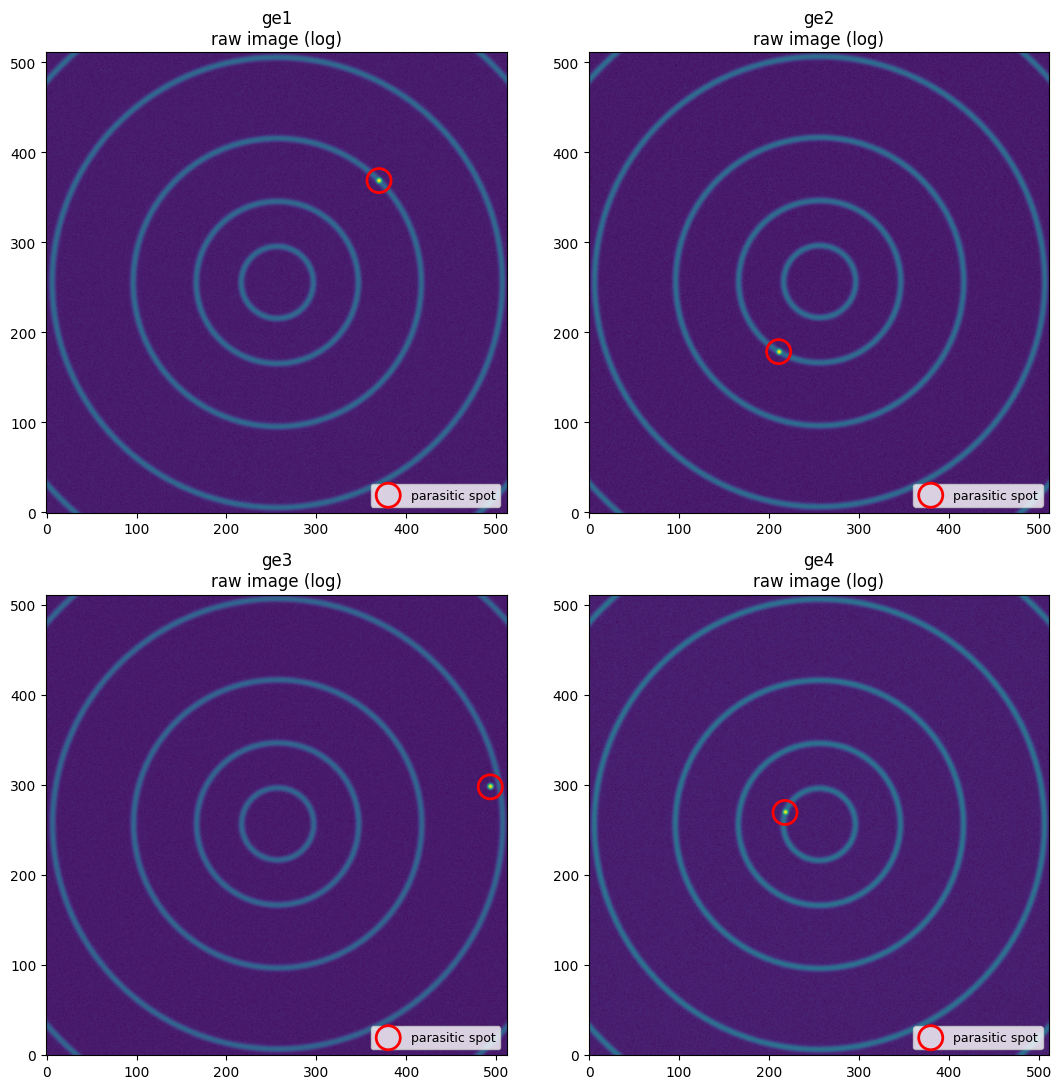

Saved nb13_01_raw_panels.png


In [4]:
# Plot all four raw panels with the planted spot location annotated.
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, name, img, (cz, cy) in zip(
    axes.flat, panel_names, panel_images, parasitic_centres
):
    im = ax.imshow(np.log1p(img), origin="lower", cmap="viridis",
                   aspect="equal")
    ax.scatter([cy], [cz], facecolors="none", edgecolors="red",
               s=300, linewidths=2.0, label="parasitic spot")
    ax.set_title(f"{name}\nraw image (log)")
    ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("nb13_01_raw_panels.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved nb13_01_raw_panels.png")


You can clearly see the four powder rings on each panel (they curve
differently because the beam-centre is at a different position per
panel — typical tiled-detector behaviour). The red circles mark the
planted parasitic Bragg spots.

## Step 2 — Build one HardBinGeometry per panel

Each panel needs its own `HardBinGeometry` because the per-pixel
(R, η) assignment depends on the panel's specific beam centre + tilts.
We share the radial binning (`RMin`, `RMax`, `RBinSize`, η bins) so the
panels can be merged onto a common axis later.


In [5]:
panel_geoms = [HardBinGeometry.from_spec(s) for s in panel_specs]
for k, g in enumerate(panel_geoms):
    print(f"  {panel_names[k]}: {g.n_valid:>7,} valid pixels, "
          f"n_r={g.n_r}, n_eta={g.n_eta}")


  ge1: 260,881 valid pixels, n_r=190, n_eta=360
  ge2: 260,889 valid pixels, n_r=190, n_eta=360
  ge3: 260,888 valid pixels, n_r=190, n_eta=360
  ge4: 260,885 valid pixels, n_r=190, n_eta=360


## Step 3 — Apply the per-ring azimuthal sigma-clip

This is the one-line call. `n_sigma=5.0` is the default. For each
radial bin in each panel:
1. Gather valid pixels with that `r_bin`.
2. Compute robust median + MAD over the η-distributed intensities.
3. Flag pixels exceeding `median + 5 · 1.4826 · MAD`.

Pixels that fail are replaced with the per-ring median in the cleaned
image (or NaN, or just flagged — controllable via `mode=`).


In [6]:
cleaned_imgs, masks = azimuthal_sigma_clip_multi_panel(
    panel_images, panel_geoms, n_sigma=5.0,
)
for k, (m, g) in enumerate(zip(masks, panel_geoms)):
    n_flag = int(m.sum())
    n_valid = g.n_valid
    pct = 100.0 * n_flag / max(n_valid, 1)
    print(f"  {panel_names[k]}: {n_flag:>4} pixels flagged "
          f"({pct:.3f}% of {n_valid:,} valid)")


  ge1:   44 pixels flagged (0.017% of 260,881 valid)
  ge2:   40 pixels flagged (0.015% of 260,889 valid)
  ge3:   64 pixels flagged (0.025% of 260,888 valid)
  ge4:   39 pixels flagged (0.015% of 260,885 valid)


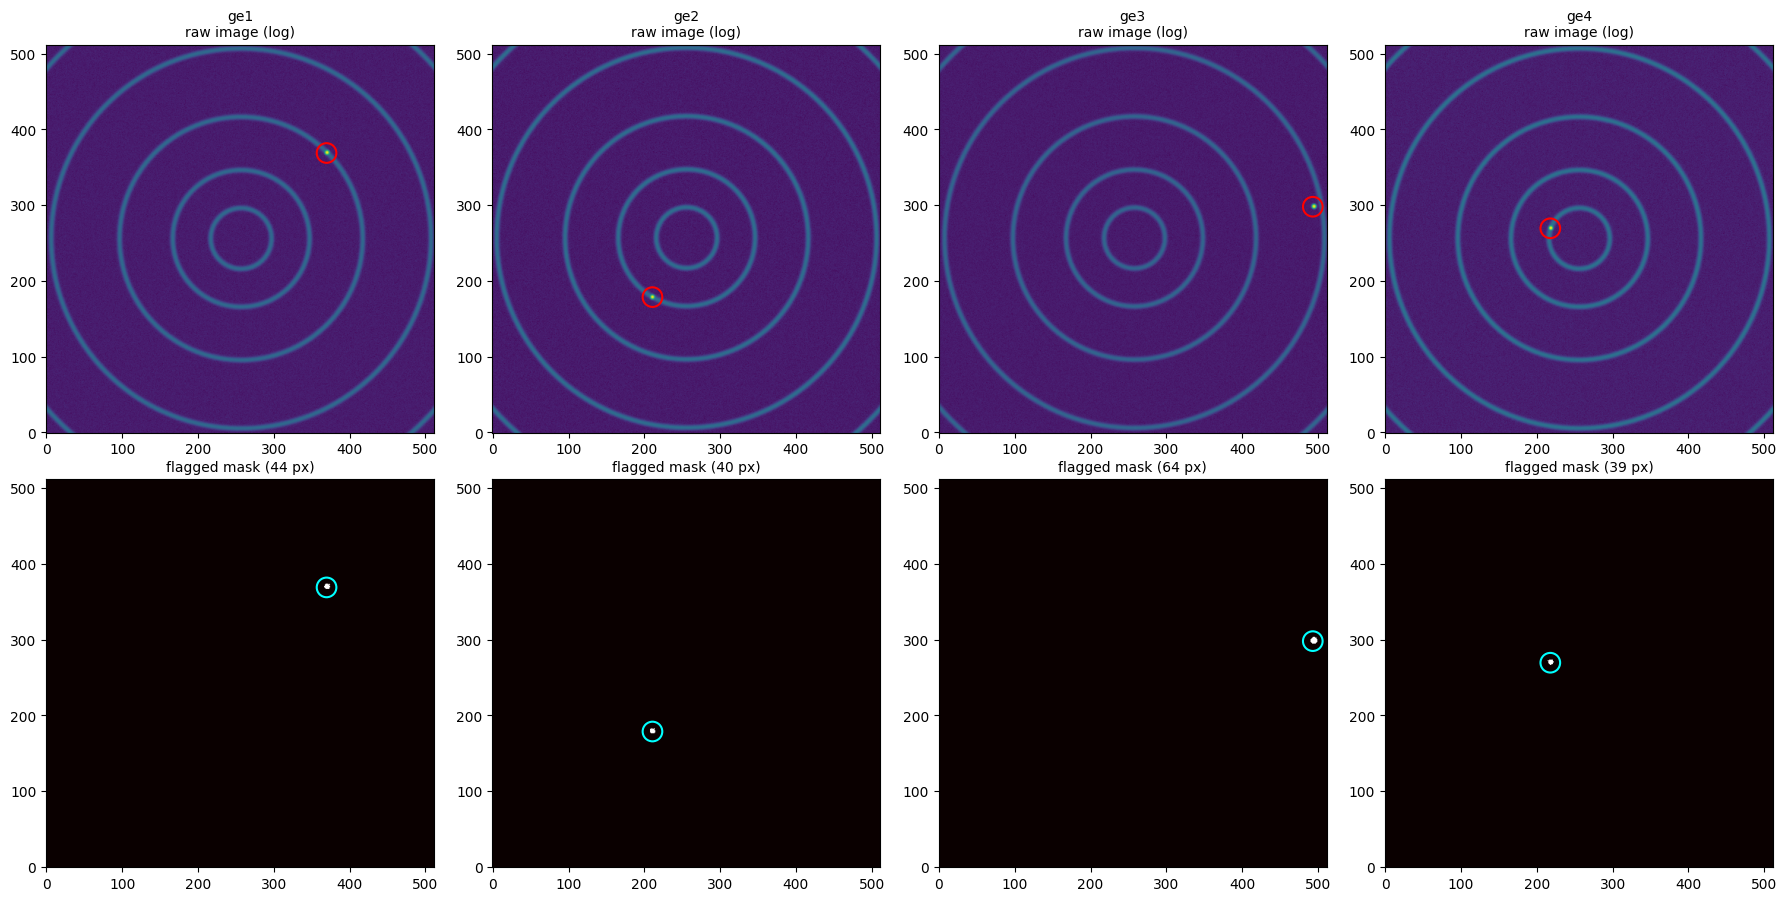

Saved nb13_02_masks.png


In [7]:
# Visualise the masks alongside the raw images. The mask is sparse —
# only the parasitic spot region lights up. The powder rings, despite
# being bright, do NOT light up because each ring is η-uniform: the MAD
# captures the noise, and no pixel deviates beyond 5σ.
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, (name, img, m, (cz, cy)) in enumerate(
    zip(panel_names, panel_images, masks, parasitic_centres)
):
    ax_img = axes[0, col]
    ax_msk = axes[1, col]

    ax_img.imshow(np.log1p(img), origin="lower", cmap="viridis", aspect="equal")
    ax_img.scatter([cy], [cz], facecolors="none", edgecolors="red",
                   s=200, linewidths=1.5)
    ax_img.set_title(f"{name}\nraw image (log)", fontsize=10)

    ax_msk.imshow(m, origin="lower", cmap="hot", aspect="equal")
    ax_msk.scatter([cy], [cz], facecolors="none", edgecolors="cyan",
                   s=200, linewidths=1.5)
    ax_msk.set_title(f"flagged mask ({int(m.sum())} px)", fontsize=10)
plt.tight_layout()
plt.savefig("nb13_02_masks.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved nb13_02_masks.png")


**Sanity check the masks**:
- Each mask is sparse — just the planted spot and a small halo around it.
- The powder rings themselves do *not* fire even though they're bright
  (constant η, so they're at-the-median for their ring).
- Inter-panel cross-talk is zero — each panel is processed
  independently.

## Step 4 — Combined I(2θ) profile via MILK adapter (before vs after)

The whole point of cleaning per-panel is to merge cleaned panels onto
a unified radial axis. `MILKMultiGeometryAdapter` does that — same
interface as pyFAI's `MultiGeometry`, but routed through v2's polygon
kernel with σ propagation.

We integrate the **raw** vs **cleaned** stacks and compare. The
parasitic spots should produce visible 'humps' in the raw I(2θ);
the cleaned profile should match a pure-powder pattern.


In [8]:
# MILK adapter takes a list of specs and integrates them onto a common
# radial axis. We pass the same npt for both runs so the axes match.
adapter = MILKMultiGeometryAdapter(panel_specs)
npt = 400

raw_res = adapter.integrate1d(panel_images,    npt, method="polygon")
cln_res = adapter.integrate1d(cleaned_imgs,    npt, method="polygon")

print(f"Combined radial axis: {npt} points, "
      f"range [{raw_res.radial[0]:.2f}, {raw_res.radial[-1]:.2f}] px")
print(f"σ propagated end-to-end: yes")


/Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/midas_integrate_v2/io/milk.py:191: RuntimeWarning: divide by zero encountered in divide
  inv_var = np.where(sig_stack > 0, 1.0 / (sig_stack ** 2), 0.0)


Combined radial axis: 400 points, range [0.24, 4.56] px
σ propagated end-to-end: yes


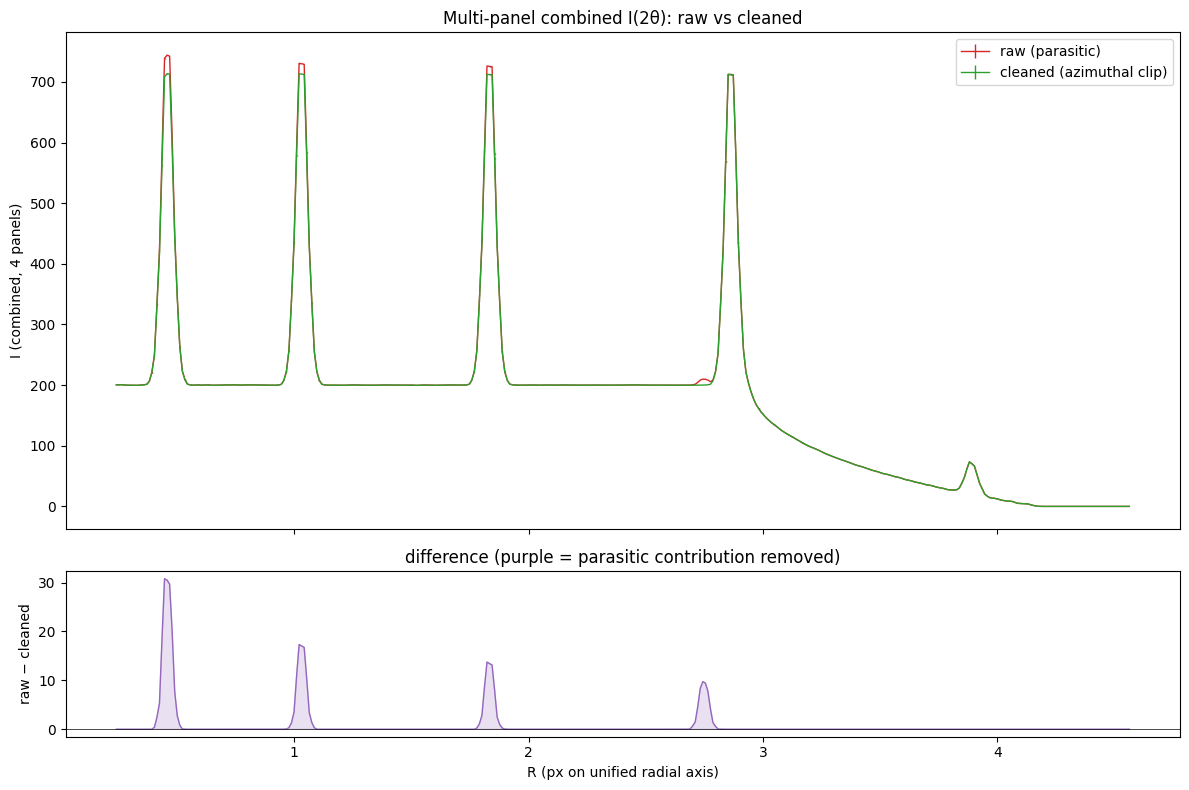

Saved nb13_03_profile_compare.png


In [9]:
# Plot raw vs cleaned, and the difference.
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8),
                                      sharex=True,
                                      gridspec_kw={"height_ratios": [3, 1]})

ax_top.errorbar(raw_res.radial, raw_res.intensity, yerr=raw_res.sigma,
                color="tab:red", lw=1.0, label="raw (parasitic)")
ax_top.errorbar(cln_res.radial, cln_res.intensity, yerr=cln_res.sigma,
                color="tab:green", lw=1.0, label="cleaned (azimuthal clip)")
ax_top.set_ylabel("I (combined, 4 panels)")
ax_top.legend(loc="upper right")
ax_top.set_title("Multi-panel combined I(2θ): raw vs cleaned")

diff = raw_res.intensity - cln_res.intensity
ax_bot.plot(cln_res.radial, diff, color="tab:purple", lw=1.0)
ax_bot.axhline(0, color="black", lw=0.5)
ax_bot.fill_between(cln_res.radial, 0, diff, where=diff > 0,
                    color="tab:purple", alpha=0.2)
ax_bot.set_xlabel("R (px on unified radial axis)")
ax_bot.set_ylabel("raw − cleaned")
ax_bot.set_title("difference (purple = parasitic contribution removed)")

plt.tight_layout()
plt.savefig("nb13_03_profile_compare.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved nb13_03_profile_compare.png")


The cleaned profile is visibly smoother — the parasitic spots, each on
a *different* ring of a *different* panel, were leaking into the
combined I(2θ) at several radii. After cleaning, the difference is
positive everywhere a spot landed and zero elsewhere.

This is the diagnostic you want: **the cleaning is energy-conserving
on the powder rings** (zero difference) but **selectively removes the
parasitic contribution** (sharp positive bumps in the residual).

## Step 5 — Sweep `n_sigma` to see the detection threshold

`n_sigma=5.0` is a sensible default, but how does the detection
quality scale with the threshold? Below ~3σ we'd risk flagging
legitimate ring fluctuations; above ~10σ we'd miss weaker parasitic
contributions.


In [10]:
sigma_values = [3.0, 4.0, 5.0, 6.0, 8.0, 12.0]
flag_counts = []
for ns in sigma_values:
    _, masks_s = azimuthal_sigma_clip_multi_panel(
        panel_images, panel_geoms, n_sigma=ns,
    )
    total = sum(int(m.sum()) for m in masks_s)
    flag_counts.append(total)
    print(f"  n_sigma={ns:>5.1f}: {total:>6} pixels flagged across all 4 panels")


  n_sigma=  3.0:   1565 pixels flagged across all 4 panels


  n_sigma=  4.0:    227 pixels flagged across all 4 panels


  n_sigma=  5.0:    187 pixels flagged across all 4 panels


  n_sigma=  6.0:    171 pixels flagged across all 4 panels


  n_sigma=  8.0:    161 pixels flagged across all 4 panels


  n_sigma= 12.0:    144 pixels flagged across all 4 panels


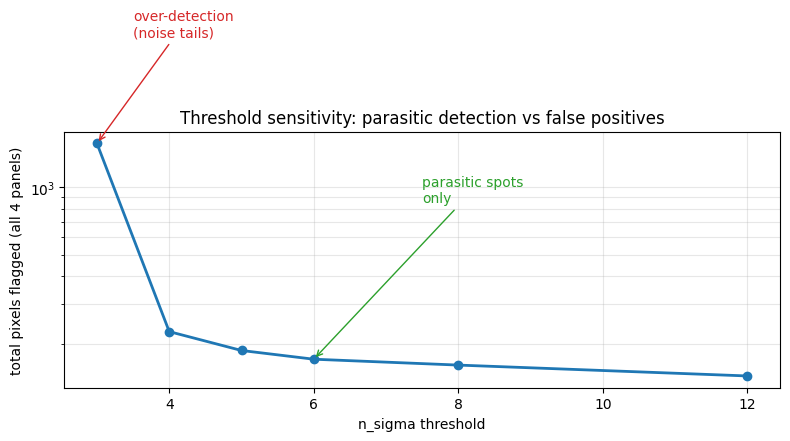

Saved nb13_04_threshold_sweep.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(sigma_values, flag_counts, "o-", color="tab:blue", lw=2.0)
ax.set_xlabel("n_sigma threshold")
ax.set_ylabel("total pixels flagged (all 4 panels)")
ax.set_title("Threshold sensitivity: parasitic detection vs false positives")
ax.grid(True, alpha=0.3, which="both")
# Annotate the regime where parasitic detection plateaus
ax.annotate("over-detection\n(noise tails)", xy=(3.0, flag_counts[0]),
            xytext=(3.5, flag_counts[0] * 3), color="tab:red", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.annotate("parasitic spots\nonly", xy=(6.0, flag_counts[3]),
            xytext=(7.5, flag_counts[3] * 5), color="tab:green", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="tab:green"))
plt.tight_layout()
plt.savefig("nb13_04_threshold_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved nb13_04_threshold_sweep.png")


**Reading the curve**:
- At 3σ, hundreds of pixels are flagged — most are noise tails on the
  rings, not real parasitic signal.
- By 5–6σ the count plateaus at the actual planted spots + their immediate
  Gaussian halo.
- Above ~10σ, only the bright spot cores are flagged; some peripheral
  spot pixels are missed.

The "elbow" between 4σ and 6σ is the practical operating window for
single-frame parasitic detection on a powder ring.

## Step 6 — When to chain this with other cleaners

For real-world workflows, azimuthal clip is one stage in a pipeline:

```python
# Recommended pipeline order:
# 1. Static panel masks (beam stop, dead modules, inter-tile gaps)
mask = build_panel_gap_mask(panel_specs)

# 2. Cosmic-ray rejection (temporal MAD across sweep — if you have
#    multiple frames at the same sample orientation)
images_stack = sweep_loader(...)
images_clean_temporal, _ = reject_cosmic_rays(images_stack)

# 3. Azimuthal clip per frame (this notebook) — single-frame, catches
#    parasitic Bragg spots that the temporal step misses
panel_images_az_cleaned, _ = azimuthal_sigma_clip_multi_panel(
    images_clean_temporal, panel_geoms,
)

# 4. Combined integration
adapter = MILKMultiGeometryAdapter(panel_specs)
result = adapter.integrate1d(panel_images_az_cleaned, npt=2000)
```

The static mask (1) handles dead silicon; (2) handles cosmic rays;
(3) handles parasitic crystals — and they compose because each
operates on a different invariant of the data.

## What's next

- **Notebook 14**: σ-aware downstream use — feeding the cleaned profile
  into PDFgetX3 / Rietveld with the propagated uncertainty.
- **Production**: `streaming/integrate_stream.py` accepts a per-frame
  callback — you can wire `azimuthal_sigma_clip_multi_panel` in as a
  preprocessing step inside the stream loop with no buffer.
